In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
hist_df=pd.read_csv("data.csv")
hist_df.head()

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


In [3]:
train_data=hist_df

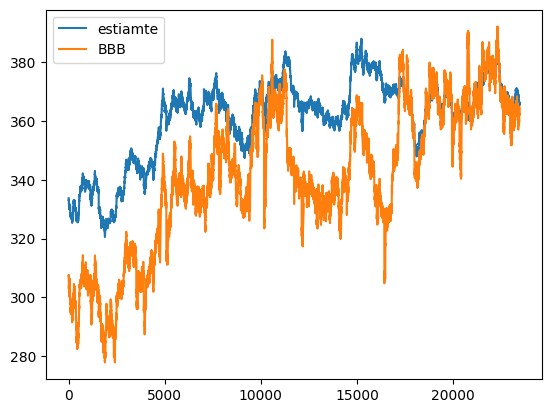

In [4]:
intercept,coef=95.46931822547003,1.05311287
sd=4.31792969543484

secutiry1="ETF"
secutiry2="BBB"

y_fit=train_data[secutiry1]*coef+intercept
plt.plot(y_fit, label="estiamte")
plt.plot(train_data[secutiry2],label=secutiry2)
#plt.plot(test_data["IND"],label=["IND"])

plt.legend()

In [5]:
train_data.index

RangeIndex(start=0, stop=23460, step=1)

In [6]:
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(filename='example.log', encoding='utf-8', level=logging.DEBUG)
logger.debug('This message should go to the log file')

In [7]:
diff=train_data[secutiry2]-y_fit
x=np.linspace(0,3,5)
y=np.linspace(0,2,5)
all=[]
bought=0

mean=-1.0595512300584884

for buy_in in x:
    for back in y:
        start_capital=1000000
        total=start_capital
        tot_ETF=0
        tot_IND=0

        profit=[1]

        for i in train_data.index:
            if(i==0): continue

            #sell etf at high
            logger.debug(f"time {i}, diff[i] {diff[i]},comp {mean+buy_in*sd},bought {bought}")
            if(diff[i]>=mean+buy_in*sd and bought==0):
                amount_etf=total//2//train_data[secutiry2][i]
                amount_ind=total//2//train_data[secutiry1][i]

                tot_IND+=amount_ind
                tot_ETF-=amount_etf

                total+=amount_etf*train_data[secutiry2][i]
                total-=amount_ind*train_data[secutiry1][i]
                bought=1
                #print(tot_ETF,i,total)

            elif(diff[i]<=mean+back*sd and tot_ETF<0 and bought==1):
                total-=tot_ETF*train_data[secutiry2][i]
                total+=tot_IND*train_data[secutiry1][i]
                tot_ETF=0
                tot_IND=0
                bought=0
                #print(tot_ETF,i,total)

            #buy etf at low
            elif(diff[i]<=mean-buy_in*sd and bought==0):
                amount_etf=total//2//train_data[secutiry2][i]
                amount_ind=total//2//train_data[secutiry1][i]

                tot_IND-=amount_ind
                tot_ETF+=amount_etf

                total-=amount_etf*train_data[secutiry2][i]
                total+=amount_ind*train_data[secutiry1][i]
                bought=1
                #print(tot_ETF,i,total)

            #go back
            elif(diff[i]>=mean-back*sd and tot_ETF>0 and bought==1):
                total+=tot_ETF*train_data[secutiry2][i]
                total-=tot_IND*train_data[secutiry1][i]
                tot_ETF=0
                tot_IND=0
                bought=0
                #print(tot_ETF,i,total)


            profit.append(total/start_capital)


        profit=pd.DataFrame(np.array(profit))

        Rp=total/start_capital

        Rf=(train_data["IND"][23459]/train_data["IND"][0])
        #train_data["IND"]
        sigma=np.sqrt(profit[0].var())

        sharpe=(Rp-Rf)/sigma
        all.append((sharpe,total,buy_in,back))
 



C:\Users\ruimi\AppData\Local\Temp\ipykernel_4084\4031570879.py:77: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe=(Rp-Rf)/sigma


KeyboardInterrupt: 

In [9]:
all.sort(reverse=True)

for i in range(5):
    print(all[i])

(np.float64(8.476374079931517), np.float64(1.4033316596269127e+70), np.float64(0.0), np.float64(0.0))
(np.float64(-inf), 1000000, np.float64(3.0), np.float64(2.0))
(np.float64(-inf), 1000000, np.float64(3.0), np.float64(1.5))
(np.float64(-inf), 1000000, np.float64(3.0), np.float64(1.0))
(np.float64(-inf), 1000000, np.float64(3.0), np.float64(0.5))
